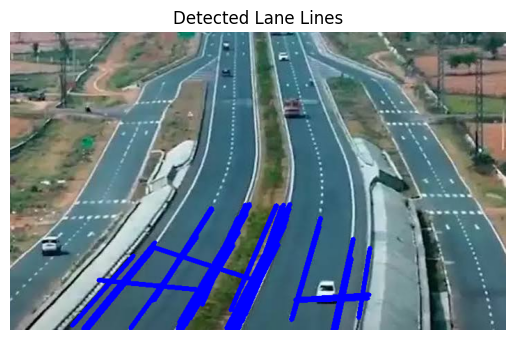

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread("road.jpg")
if image is None:
  raise FileNotFoundError("road.jgp not found")

output=image.copy()
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
blur=cv2.GaussianBlur(gray,(5,5),0)
edges=cv2.Canny(blur,50,150)
h,w=edges.shape
mask=np.zeros_like(edges)

polygon=np.array([[
    (0,h),
    (w,h),
    (int(0.58*w),int(0.58*h)),
    (int(0.42*w),int(0.58*h)),
]],dtype=np.int32)

cv2.fillPoly(mask,polygon,255)
roi_edges=cv2.bitwise_and(edges,mask)

lines = cv2.HoughLinesP(roi_edges,rho=1,theta=np.pi/100,threshold=30,minLineLength=100,maxLineGap=50)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 5)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Detected Lane Lines')
plt.axis('off')
plt.show()